<a href="https://colab.research.google.com/github/no0orang/CoLab/blob/main/2026_06_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2026.06.24 5:00~
GPT 따라해보기

Ctrl + M + B : 새로운 코드 생성

Ctrl + Enter : 코드 실행


numpy = 계산기

pandas = excel

matplotlib = graphpad

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# numpy, pandas, matplotlib 불러오기
# 이거 실행 안하고 사용하면 에러 뜸

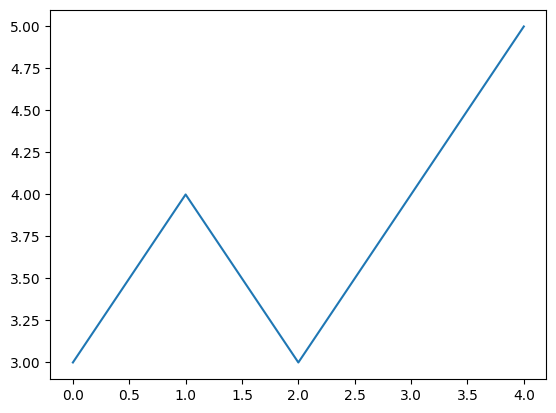

In [ ]:
data = [3, 4, 3, 4, 5]

plt.plot(data)
plt.show()

In [ ]:
data = {
    "gene": ["TP53", "BRCA1", "EGFR", "MYC", "CDK2"],
    "control": [5, 2, 8, 6, 3],
    "cancer": [15, 10, 20, 18, 9]
}

df = pd.DataFrame(data)
df

,gene,control,cancer
0,TP53,5,15
1,BRCA1,2,10
2,EGFR,8,20
3,MYC,6,18
4,CDK2,3,9


In [ ]:
df["log2_fold_change"] = np.log2(df["cancer"] / df["control"])
df

,gene,control,cancer,log2_fold_change
0,TP53,5,15,1.584963
1,BRCA1,2,10,2.321928
2,EGFR,8,20,1.321928
3,MYC,6,18,1.584963
4,CDK2,3,9,1.584963


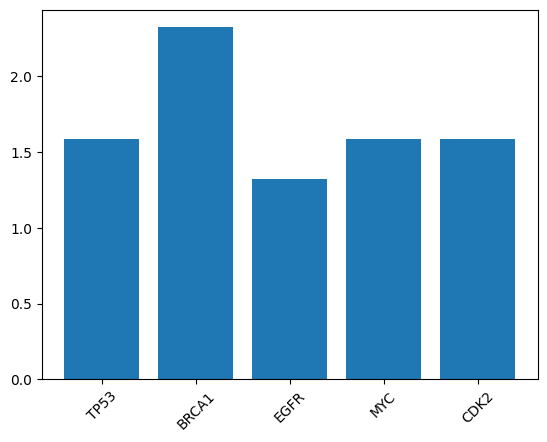

In [ ]:
plt.bar(df["gene"], df["log2_fold_change"])
plt.xticks(rotation=45)
plt.show()

In [ ]:
!pip install GEOparse pandas numpy matplotlib seaborn

In [ ]:
import GEOparse

# GEOparse는 import하려면 위의 코드로 받아줘야함. 나머지 3개는 안쳐도 작동하는거 보면 이미 기본으로 받아져 있는듯

In [ ]:
gse = GEOparse.get_GEO("GSE10072", destdir="./")

# GEO site에서 데이터 세트마다 부여된 GSE ID를 입력하여 다운 가능

23-Jun-2026 20:12:09 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
23-Jun-2026 20:12:09 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/soft/GSE10072_family.soft.gz to ./GSE10072_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/soft/GSE10072_family.soft.gz to ./GSE10072_family.soft.gz
100%|██████████| 25.6M/25.6M [00:03<00:00, 7.31MB/s]
23-Jun-2026 20:12:13 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
23-Jun-2026 20:12:13 DEBUG downloader - Moving /tmp/tmpc3ujdyr6 to /content/GSE10072_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpc3ujdyr6 to /content/GSE10072_family.soft.gz
23-Jun-2026 20:12:13 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/soft/GSE10072_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10

In [ ]:
print(gse)

<SERIES: GSE10072 - 107 SAMPLES, 1 d(s)>


In [ ]:
gse.gsms.keys()

dict_keys(['GSM254625', 'GSM254626', 'GSM254627', 'GSM254628', 'GSM254629', 'GSM254630', 'GSM254631', 'GSM254632', 'GSM254633', 'GSM254634', 'GSM254635', 'GSM254636', 'GSM254637', 'GSM254638', 'GSM254639', 'GSM254640', 'GSM254641', 'GSM254642', 'GSM254643', 'GSM254644', 'GSM254645', 'GSM254646', 'GSM254647', 'GSM254648', 'GSM254649', 'GSM254650', 'GSM254651', 'GSM254652', 'GSM254653', 'GSM254654', 'GSM254655', 'GSM254656', 'GSM254657', 'GSM254658', 'GSM254659', 'GSM254660', 'GSM254661', 'GSM254662', 'GSM254663', 'GSM254664', 'GSM254665', 'GSM254666', 'GSM254667', 'GSM254668', 'GSM254669', 'GSM254670', 'GSM254671', 'GSM254672', 'GSM254673', 'GSM254674', 'GSM254675', 'GSM254676', 'GSM254677', 'GSM254678', 'GSM254679', 'GSM254680', 'GSM254681', 'GSM254682', 'GSM254683', 'GSM254684', 'GSM254685', 'GSM254686', 'GSM254687', 'GSM254688', 'GSM254689', 'GSM254690', 'GSM254691', 'GSM254692', 'GSM254693', 'GSM254694', 'GSM254695', 'GSM254696', 'GSM254697', 'GSM254698', 'GSM254699', 'GSM254700', '

In [ ]:
sample_name = list(gse.gsms.keys())[0]
gsm = gse.gsms[sample_name]

df = gsm.table
df.head()

# AFFX: Affymetrix control probe, 이전 데이터셋에서 나옴. 가공되지 않은 데이터라 입문 단계에서 적합하지 않다고 판단하여 다른 데이터셋을 가져왔음.

,ID_REF,VALUE
0,1007_s_at,10.927084
1,1053_at,6.895217
2,117_at,8.110190
3,121_at,9.451286
4,1255_g_at,4.814477


In [ ]:
import pandas as pd

all_samples = {}

for gsm_name in gse.gsms.keys():
    gsm = gse.gsms[gsm_name]
    df = gsm.table
    all_samples[gsm_name] = df["VALUE"].values

In [ ]:
expression_df = pd.DataFrame(all_samples)
expression_df.head()

,GSM254625,GSM254626,GSM254627,GSM254628,GSM254629,GSM254630,GSM254631,GSM254632,GSM254633,GSM254634,...,GSM254722,GSM254723,GSM254724,GSM254725,GSM254726,GSM254727,GSM254728,GSM254729,GSM254730,GSM254731
0,10.927084,10.416978,10.628538,10.151180,10.988512,10.778205,10.568814,10.479425,10.548843,10.465005,...,10.727493,10.740353,10.527962,10.193615,10.768815,10.467693,10.902778,10.869402,10.292285,10.407218
1,6.895217,6.924856,7.550245,6.699557,6.826031,6.718372,6.739765,6.724615,7.102475,6.627922,...,6.856575,6.737879,6.959032,7.008578,6.740444,6.795750,6.838162,6.628363,6.794050,6.358410
2,8.110190,7.760228,7.974676,7.712676,7.775592,7.777087,7.893210,8.058398,8.005438,7.961476,...,7.741922,7.805107,8.093078,8.144760,8.159483,7.855457,8.010428,7.889019,8.163266,7.973844
3,9.451286,9.520943,9.807597,9.522087,9.855061,9.861055,10.126183,9.878970,10.110318,10.411478,...,10.089149,10.007059,9.832610,10.107004,9.790645,9.645239,9.871851,9.867988,9.824801,9.850144
4,4.814477,4.718640,4.905163,4.818076,4.823958,4.848313,5.125956,5.037979,4.889936,5.177818,...,5.048391,4.758050,4.900470,4.948760,4.609322,4.759571,4.788774,4.967626,4.817474,5.128892


In [ ]:
expression_df.mean()

,0
GSM254625,7.529112
GSM254626,7.522747
GSM254627,7.544572
GSM254628,7.531137
GSM254629,7.511000
...,...
GSM254727,7.534036
GSM254728,7.526384
GSM254729,7.544898
GSM254730,7.524430


In [ ]:
expression_df.loc["1007_s_at"]

KeyError: '1007_s_at'

GPT 썼는데 dataset을 가져와놓고 어떤 데이터가 있는지 몰라서 결과가 제대로 안나옴..
일단 Gemini한테 배워보기로..

In [ ]:
# 1. R 매직 명령어 활성화
%load_ext rpy2.ipython

In [ ]:
# 2. BiocManager 및 GEOquery 설치 (R 코드 실행)
%%R
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install(c("GEOquery", "limma", "Biobase"), update = FALSE, ask = FALSE)
install.packages("tidyverse") # 데이터 가공 및 시각화용

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'GEOquery'
also installing the dependency ‘SummarizedExperiment’

trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/SummarizedExperiment_1.42.0.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/GEOquery_2.80.0.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpNLyyUh/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/tidyverse_2.0.0.tar.gz'
Content type 'application/x-gzip' length 704618 bytes (688 KB)
downloaded 688 KB


The downloaded source packages are in
	‘/tmp/RtmpNLyyUh/downloaded_packages’
In addition: Warning message:
package(s) not installed when v

In [ ]:
%%R
library(GEOquery)
library(Biobase)

# 원하는 GSE 번호 입력
gse_id <- "GSE12345"
gset <- getGEO(gse_id, GSEMatrix = TRUE, AnnotGPL = TRUE)

# 데이터가 리스트 형태로 들어오므로 첫 번째 데이터셋 선택
if (length(gset) > 1) idx <- grep("GPL", attr(gset, "names")) else idx <- 1
gset <- gset[[idx]]

Loading required package: Biobase
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', a

In [ ]:
%%R
# 1. 발현량 데이터 확인
expr_data <- exprs(gset)
print(dim(expr_data)) # 유전자 수 x 샘플 수 확인
print(head(expr_data[, 1:5])) # 앞부분 5개 샘플 보기

# 2. 샘플 정보(실험군 vs 대조군 등) 확인
sample_info <- pData(gset)
print(head(sample_info[, c("title", "characteristics_ch1")]))

# 3. 데이터 Log2 변환 여부 확인 및 필요시 변환 (Normalization)
qx <- as.numeric(quantile(expr_data, c(0., 0.25, 0.5, 0.75, 0.99, 1.0), na.rm=T))
LogC <- (qx[5] > 100) || (qx[6]-qx[1] > 50 && qx[2] > 0)
if (LogC) {
  expr_data[expr_data <= 0] <- NaN
  expr_data <- log2(expr_data)
  print("Log2 변환을 완료했습니다.")
}

[1] 54675    13
          GSM309986 GSM309987 GSM309988 GSM309989 GSM309990
1007_s_at  9.224366  9.452484  6.088917  8.779084 11.594373
1053_at    7.343050  7.245155  7.945808  7.300137  7.402575
117_at     5.241737  6.609800  8.018336  9.034880  6.061666
121_at     6.499194  6.458844  7.300338  6.822188  6.499194
1255_g_at  2.187841  2.187841  2.376542  2.187841  2.187841
1294_at    6.158794  8.973800  8.122865  9.345717  8.094151
                                                                             title
GSM309986 Global gene expression profiling of human pleural mesotheliomas; ctrl 14
GSM309987  Global gene expression profiling of human pleural mesotheliomas; ctrl 8
GSM309988 Global gene expression profiling of human pleural mesotheliomas; ctrl 48
GSM309989 Global gene expression profiling of human pleural mesotheliomas; ctrl 47
GSM309990 Global gene expression profiling of human pleural mesotheliomas; meso 21
GSM309991 Global gene expression profiling of human pleural mesoth

In [ ]:
%%R
library(limma)

# 예시: 샘플 정보에서 그룹 나누기 (실제 데이터에 맞게 수정 필요)
# 여기서는 편의상 앞의 절반을 Control, 뒤의 절반을 Disease로 가정
gsms <- paste0(rep(c("0", "1"), each = ncol(expr_data)/2), collapse="")
sml <- strsplit(gsms, split="")[[1]]

# 디자인 매트릭스 생성
groups <- as.factor(sml)
levels(groups) <- c("Control", "Disease")
design <- model.matrix(~ groups)
colnames(design) <- c("Control", "DiseasevsControl")

# limma 파이프라인 실행
fit <- lmFit(expr_data, design)
fit <- eBayes(fit)
tT <- topTable(fit, coef="DiseasevsControl", adjust="fdr", sort.by="B", number=250)

# 결과 확인 (Top 10 DEGs)
print(head(tT[, c("Gene.symbol", "logFC", "P.Value", "adj.P.Val")]))

Error in lmFit(expr_data, design) : 
  row dimension of design doesn't match column dimension of data object


RInterpreterError: Failed to parse and evaluate line 'library(limma)\n\n# 예시: 샘플 정보에서 그룹 나누기 (실제 데이터에 맞게 수정 필요)\n# 여기서는 편의상 앞의 절반을 Control, 뒤의 절반을 Disease로 가정\ngsms <- paste0(rep(c("0", "1"), each = ncol(expr_data)/2), collapse="")\nsml <- strsplit(gsms, split="")[[1]]\n\n# 디자인 매트릭스 생성\ngroups <- as.factor(sml)\nlevels(groups) <- c("Control", "Disease")\ndesign <- model.matrix(~ groups)\ncolnames(design) <- c("Control", "DiseasevsControl")\n\n# limma 파이프라인 실행\nfit <- lmFit(expr_data, design)\nfit <- eBayes(fit)\ntT <- topTable(fit, coef="DiseasevsControl", adjust="fdr", sort.by="B", number=250)\n\n# 결과 확인 (Top 10 DEGs)\nprint(head(tT[, c("Gene.symbol", "logFC", "P.Value", "adj.P.Val")]))\n'.
R error message: "Error in lmFit(expr_data, design) : \n  row dimension of design doesn't match column dimension of data object"

In [ ]:
%%R
# 간단한 Volcano Plot 그릴 수 있는 패키지 설치 및 실행
if (!requireNamespace("EnhancedVolcano", quietly = TRUE))
    BiocManager::install("EnhancedVolcano")

library(EnhancedVolcano")

EnhancedVolcano(tT,
    lab = tT$Gene.symbol,
    x = 'logFC',
    y = 'adj.P.Val',
    pCutoff = 0.05,
    FCcutoff = 1.0,
    pointSize = 3.0,
    labSize = 4.0,
    title = 'Control vs Disease DEGs')

얘는 step 2부터 실행이 안되네;
실행됐는데 에러떠서 다음에 해보기로
~ 5:28